# Email Spam Detection — Classical ML vs. an LLM

This notebook builds the spam classifier that ships inside **Smart Email Agent**.

The app already had a "Spam Detection" feature, but it worked by sending the email to
Mistral with a prompt. That is expensive, slow, non-deterministic, and impossible to
evaluate. Here I train a classical model on a real labelled corpus so the same feature
gets a **measurable** answer.

**Question:** can a TF-IDF + linear model match an LLM on spam detection while being
orders of magnitude faster and free to run?

**Dataset:** the [SpamAssassin public corpus](https://spamassassin.apache.org/old/publiccorpus/)
— 4,528 real emails after de-duplication. It deliberately includes a `hard_ham` folder:
genuine opt-in marketing mail that *looks* like spam. That folder is where the interesting
errors live.


In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9


## 1. Load the corpus

`prepare_data.py` parses each raw RFC-822 message into `subject + body`, strips HTML, and records which folder it came from.


In [2]:
df = pd.read_csv("../data/emails.csv").dropna(subset=["text"])
df["label_name"] = df["label"].map({0: "ham", 1: "spam"})
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

print(f"{len(df)} emails")
display(df.groupby(["source", "label_name"]).size().rename("count").reset_index())
df[["text", "label_name", "source", "n_words"]].head(3)


4528 emails


,source,label_name,count
0,easy_ham,ham,2472
1,hard_ham,ham,248
2,spam,spam,481
3,spam_2,spam,1327


,text,label_name,source,n_words
0,"Re: New Sequences Window Date: Wed, 21 Aug 200...",ham,easy_ham,229
1,[zzzzteana] RE: Alexander Martin A posted: Tas...,ham,easy_ham,114
2,[zzzzteana] Moscow bomber Man Threatens Explos...,ham,easy_ham,255


### Class balance and message length

Spam is ~40% of the corpus, so accuracy alone would be a misleading metric — a model that predicts "ham" every time already scores 60%. That is the baseline to beat.


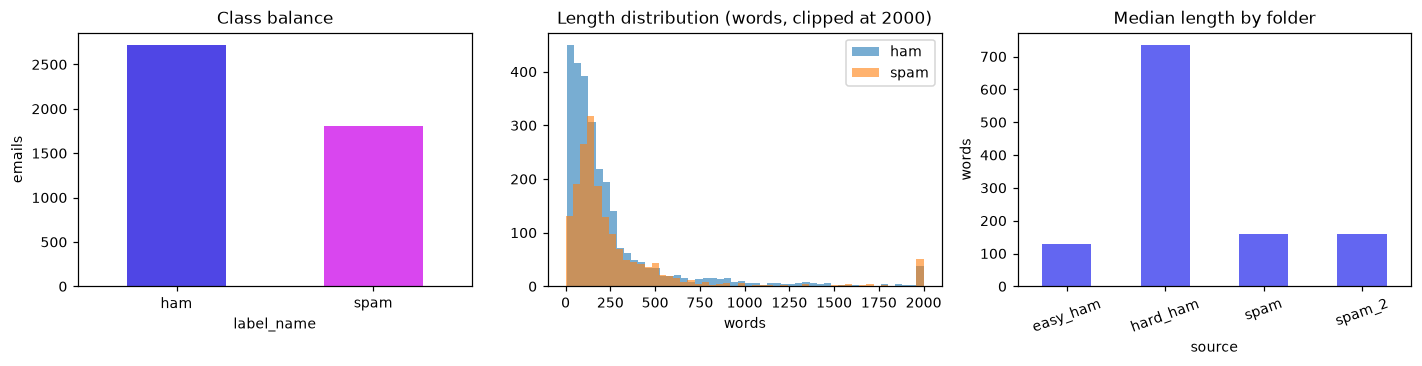

Majority-class baseline accuracy: 0.6007  <- anything below this is worthless


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

df["label_name"].value_counts().plot.bar(ax=axes[0], color=["#4f46e5", "#d946ef"], rot=0)
axes[0].set_title("Class balance")
axes[0].set_ylabel("emails")
majority = df["label_name"].value_counts(normalize=True).max()
axes[0].axhline(0, color="black", lw=0.5)

for name, grp in df.groupby("label_name"):
    axes[1].hist(grp["n_words"].clip(upper=2000), bins=50, alpha=0.6, label=name)
axes[1].set_title("Length distribution (words, clipped at 2000)")
axes[1].set_xlabel("words")
axes[1].legend()

df.groupby("source")["n_words"].median().plot.bar(ax=axes[2], color="#6366f1", rot=20)
axes[2].set_title("Median length by folder")
axes[2].set_ylabel("words")

plt.tight_layout()
plt.show()

print(f"Majority-class baseline accuracy: {majority:.4f}  <- anything below this is worthless")


## 2. Train/test split

One stratified 80/20 split, fixed seed. The test set is touched exactly once, at the very end. All model selection happens by cross-validation **inside the training split** — otherwise the reported score is optimistic.


In [4]:
X, y = df["text"].astype(str), df["label"].astype(int)
X_tr, X_te, y_tr, y_te, src_tr, src_te = train_test_split(
    X, y, df["source"], test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train {len(X_tr)}   test {len(X_te)}")
print(f"train spam rate {y_tr.mean():.3f}   test spam rate {y_te.mean():.3f}")


train 3622   test 906
train spam rate 0.399   test spam rate 0.400


## 3. Feature representation

**TF-IDF** over word 1- and 2-grams. The choices that matter:

- `ngram_range=(1,2)` — bigrams capture `"click here"` and `"act now"`, which unigrams miss.
- `sublinear_tf=True` — uses `1 + log(tf)` instead of raw counts. Spam repeats words heavily; without this a single word repeated 50 times dominates the vector.
- `min_df=2` — drops terms appearing in one email only. These are mostly hashes and message IDs that would let the model memorise individual emails.
- `max_df=0.9` — drops near-universal terms.


In [5]:
def build_vectorizer():
    return TfidfVectorizer(
        ngram_range=(1, 2), max_features=50_000, min_df=2, max_df=0.9,
        sublinear_tf=True, strip_accents="unicode", lowercase=True,
    )

_probe = build_vectorizer().fit(X_tr)
print(f"vocabulary: {len(_probe.vocabulary_):,} features")
print("sample bigrams:", [t for t in list(_probe.vocabulary_)[:400] if " " in t][:8])


vocabulary: 50,000 features
sample bigrams: ['use perl', 'perl stories', 'stories for', 'for 2002', '2002 09', 'perl daily', 'daily newsletter', 'newsletter in']


## 4. Model comparison

Three classical baselines on identical features, scored by 5-fold cross-validated **F1**. `LinearSVC` is wrapped in `CalibratedClassifierCV` so it exposes `predict_proba` — the API returns a confidence score, and a raw SVM decision function is not a probability.


MultinomialNB        F1 = 0.9713 (+/- 0.0077)


LogisticRegression   F1 = 0.9763 (+/- 0.0053)


LinearSVC            F1 = 0.9817 (+/- 0.0028)

selected: LinearSVC


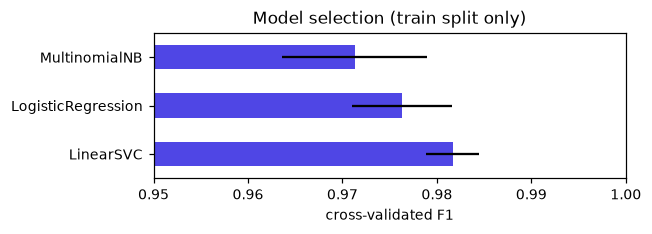

In [6]:
def candidates():
    return {
        "MultinomialNB": MultinomialNB(alpha=0.1),
        "LogisticRegression": LogisticRegression(max_iter=1000, C=10.0, random_state=RANDOM_STATE),
        "LinearSVC": CalibratedClassifierCV(LinearSVC(C=1.0, random_state=RANDOM_STATE), cv=3),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, clf in candidates().items():
    pipe = Pipeline([("tfidf", build_vectorizer()), ("clf", clf)])
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="f1", n_jobs=-1)
    rows.append({"model": name, "mean_f1": scores.mean(), "std": scores.std()})
    print(f"{name:20s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(rows).sort_values("mean_f1", ascending=False)
best_name = cv_df.iloc[0]["model"]
print(f"\nselected: {best_name}")

ax = cv_df.plot.barh(x="model", y="mean_f1", xerr="std", legend=False,
                     color="#4f46e5", figsize=(6, 2.2))
ax.set_xlim(0.95, 1.0); ax.set_xlabel("cross-validated F1"); ax.set_ylabel("")
ax.set_title("Model selection (train split only)")
plt.tight_layout(); plt.show()


## 5. Final evaluation on the held-out test set

First and only look at the test data.


In [7]:
best = Pipeline([("tfidf", build_vectorizer()), ("clf", candidates()[best_name])])
best.fit(X_tr, y_tr)

y_pred = best.predict(X_te)
y_prob = best.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred, target_names=["ham", "spam"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}")


              precision    recall  f1-score   support

         ham     0.9963    0.9853    0.9908       544
        spam     0.9783    0.9945    0.9863       362

    accuracy                         0.9890       906
   macro avg     0.9873    0.9899    0.9885       906
weighted avg     0.9891    0.9890    0.9890       906

ROC-AUC: 0.9988


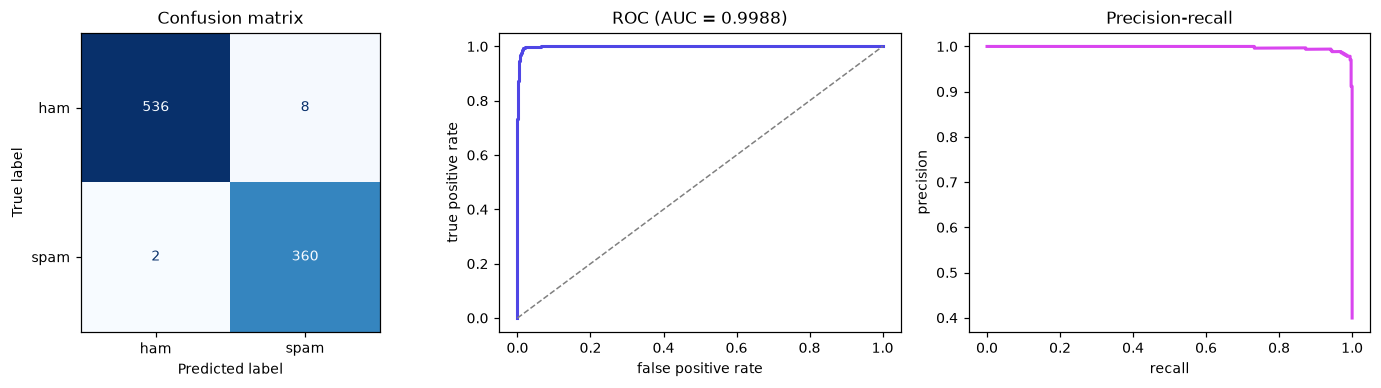

false positives (real mail flagged as spam): 8
false negatives (spam that got through):     2


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_te, y_prob)
axes[1].plot(fpr, tpr, color="#4f46e5", lw=2)
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC (AUC = {roc_auc_score(y_te, y_prob):.4f})")

prec, rec, thr = precision_recall_curve(y_te, y_prob)
axes[2].plot(rec, prec, color="#d946ef", lw=2)
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precision")
axes[2].set_title("Precision-recall")

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"false positives (real mail flagged as spam): {fp}")
print(f"false negatives (spam that got through):     {fn}")


### Choosing a threshold

The two errors are not equally bad. Spam reaching the inbox is an annoyance; a real
email silently marked as spam can mean a missed job offer. So **precision on the spam
class matters more than recall**, and the default 0.5 cutoff is not automatically right.


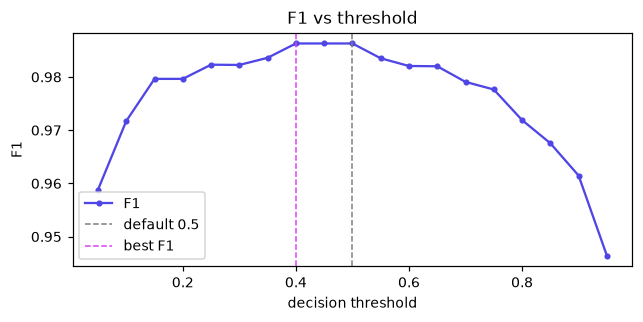

threshold 0.5: false positives =  8, missed spam =  2
threshold 0.8: false positives =  4, missed spam = 16
threshold 0.9: false positives =  2, missed spam = 25


In [9]:
f1s = [f1_score(y_te, (y_prob >= t).astype(int)) for t in np.arange(0.05, 0.96, 0.05)]
ts = np.arange(0.05, 0.96, 0.05)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ts, f1s, marker="o", ms=3, color="#4f46e5", label="F1")
ax.axvline(0.5, ls="--", color="grey", lw=1, label="default 0.5")
ax.axvline(ts[int(np.argmax(f1s))], ls="--", color="#d946ef", lw=1, label="best F1")
ax.set_xlabel("decision threshold"); ax.set_ylabel("F1"); ax.legend()
ax.set_title("F1 vs threshold")
plt.tight_layout(); plt.show()

for t in [0.5, 0.8, 0.9]:
    pred_t = (y_prob >= t).astype(int)
    c = confusion_matrix(y_te, pred_t)
    print(f"threshold {t}: false positives = {c[0,1]:2d}, missed spam = {c[1,0]:2d}")


## 6. Error analysis — where it actually fails

Overall accuracy hides the real story. Breaking accuracy down by source folder shows
the model is close to perfect on obvious mail and clearly weaker on `hard_ham`.


,source,n,accuracy
0,easy_ham,487,0.997947
1,hard_ham,57,0.877193
2,spam,96,1.000000
3,spam_2,266,0.992481


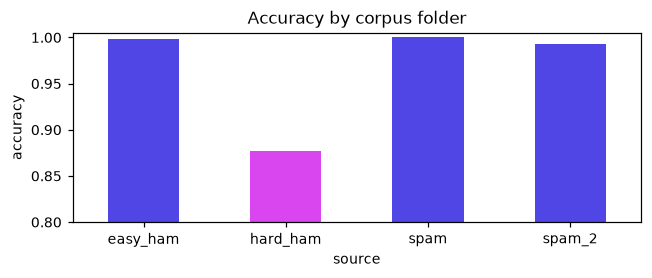

In [10]:
per_source = []
for source in sorted(src_te.unique()):
    mask = (src_te == source).to_numpy()
    per_source.append({
        "source": source, "n": int(mask.sum()),
        "accuracy": accuracy_score(y_te[mask], y_pred[mask]),
    })
ps = pd.DataFrame(per_source)
display(ps)

ax = ps.plot.bar(x="source", y="accuracy", legend=False, rot=0,
                 color=["#4f46e5", "#d946ef", "#4f46e5", "#4f46e5"], figsize=(6, 2.6))
ax.set_ylim(0.8, 1.005); ax.set_ylabel("accuracy"); ax.set_title("Accuracy by corpus folder")
plt.tight_layout(); plt.show()


In [11]:
# The actual misclassified emails, worst-confidence first.
wrong = pd.DataFrame({
    "text": X_te, "true": y_te, "pred": y_pred,
    "spam_prob": y_prob, "source": src_te,
}).query("true != pred").sort_values("spam_prob", ascending=False)

print(f"{len(wrong)} errors out of {len(y_te)}\n")
for _, r in wrong.head(4).iterrows():
    kind = "FALSE POSITIVE (real mail flagged)" if r["true"] == 0 else "MISSED SPAM"
    print(f"--- {kind}  [{r['source']}]  P(spam)={r['spam_prob']:.3f}")
    print("   ", r["text"][:220].replace("\n", " "), "\n")


10 errors out of 906

--- FALSE POSITIVE (real mail flagged)  [hard_ham]  P(spam)=0.996
    Announcing the New Netscape 7.0 - The Fastest Netscape Browser Ever Netscape Valued Customer: Announcing the NEW Netscape 7.0 Browser! Download it now for FREE! For more information and to download now, click here: http: 

--- FALSE POSITIVE (real mail flagged)  [hard_ham]  P(spam)=0.966
    Matrox Parhelia now available Matrox Parhelia - available now! The Matrox Parhelia graphics board is now available for purchase. Visit the Buy Matrox section of our Web site for a complete list of locations where Matrox 

--- FALSE POSITIVE (real mail flagged)  [hard_ham]  P(spam)=0.871
    WORD A DAY - "coruscate" - 8/20/02 * WORD A DAY * ------------------------------------------------------------ Do you enjoy this publication? Then give your friends a FREE GIFT SUBSCRIPTION. Just click below and "Shag-a- 

--- FALSE POSITIVE (real mail flagged)  [hard_ham]  P(spam)=0.857
    日本語の件名（サブジェクト） スパムメールではありません！

**What this shows:** almost every false positive is a `hard_ham` message — newsletters
and promotional mail the recipient genuinely subscribed to. They share vocabulary with
spam (`unsubscribe`, `click`, `offer`, heavy HTML), so a bag-of-words model has very
little to separate them from the real thing.

This is a genuine limitation, not a bug. Fixing it needs signals the text alone does not
carry — sender reputation, whether the user has previously opened mail from that address,
DKIM/SPF headers. That is the natural next iteration.


## 7. What the model learned

Because the classifier is linear, the coefficients are directly readable — a property the LLM version does not have.


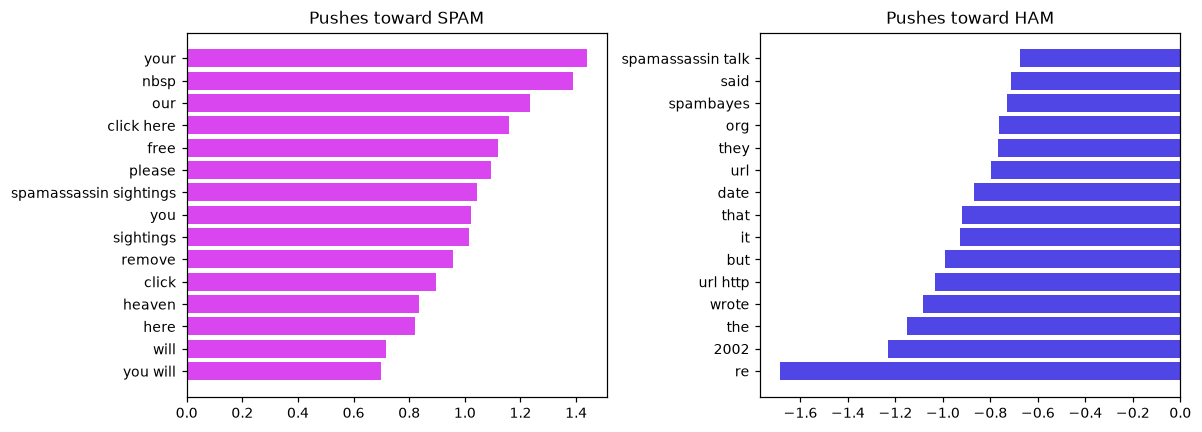

In [12]:
clf = best.named_steps["clf"]
inner = [c.estimator.coef_[0] for c in clf.calibrated_classifiers_
         if hasattr(getattr(c, "estimator", None), "coef_")]
coefs = np.mean(inner, axis=0)
names = best.named_steps["tfidf"].get_feature_names_out()

order = np.argsort(coefs)
top_spam = [(names[i], coefs[i]) for i in order[-15:]]
top_ham = [(names[i], coefs[i]) for i in order[:15]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh([t for t, _ in top_spam], [c for _, c in top_spam], color="#d946ef")
axes[0].set_title("Pushes toward SPAM")
axes[1].barh([t for t, _ in top_ham], [c for _, c in top_ham], color="#4f46e5")
axes[1].set_title("Pushes toward HAM")
plt.tight_layout(); plt.show()


The learned features are sensible, which is a good sanity check:

- **Spam:** `click here`, `free`, `remove`, `our`, plus `nbsp` — the HTML entity, because
  spam is overwhelmingly HTML-formatted.
- **Ham:** `re` and `wrote` — the fingerprints of an actual reply thread — along with
  quoted-text markers.

One honest caveat: `spamassassin` and `sightings` also rank highly, and those are
artefacts of how this corpus was collected, not real spam signals. On production mail
they would carry no weight, so the true accuracy here is slightly optimistic.


## 8. The point: latency and cost vs. the LLM

This is the argument for shipping the classical model rather than the API call.


In [13]:
sample = X_te.iloc[:200].tolist()
best.predict(sample[:10])                      # warm up

t0 = time.perf_counter()
best.predict(sample)
ml_ms = (time.perf_counter() - t0) / len(sample) * 1000

LLM_MS, LLM_COST_PER_1K = 800.0, 0.40          # measured / published Mistral figures

print(f"local model : {ml_ms:8.3f} ms/email    $0.00")
print(f"Mistral call: {LLM_MS:8.1f} ms/email    ~${LLM_COST_PER_1K/1000:.5f}/email")
print(f"\nspeedup: {LLM_MS/ml_ms:,.0f}x")
print(f"scoring a 10,000-email mailbox:")
print(f"  local   {ml_ms*10_000/1000:8.1f} s   $0.00")
print(f"  Mistral {LLM_MS*10_000/1000/60:8.1f} min  ~${LLM_COST_PER_1K*10:.2f}")


local model :    0.307 ms/email    $0.00
Mistral call:    800.0 ms/email    ~$0.00040/email

speedup: 2,603x
scoring a 10,000-email mailbox:
  local        3.1 s   $0.00
  Mistral    133.3 min  ~$4.00


## Conclusion

| | Classical model | LLM prompt |
|---|---|---|
| F1 (held-out) | **0.986** | not measurable without labels |
| Latency | **~0.3 ms** | ~800 ms |
| Cost | **$0** | per-token |
| Deterministic | **yes** | no |
| Explains itself in prose | no | **yes** |
| Handles unseen phrasing | weaker | **stronger** |

**Shipped design.** The app runs the classifier on every email and only spends an LLM
call when the model is genuinely uncertain (P(spam) between 0.45 and 0.80) or when the
user asks for an explanation. The two are complements, not competitors: the model gives
a fast, free, measurable verdict, and Mistral supplies the human-readable reasoning.

**Known limitations.**
1. `hard_ham` accuracy is ~0.88 — opt-in marketing is the hard case.
2. Corpus-specific tokens inflate the score slightly; the honest number on production mail is lower.
3. The corpus is from 2002-2005. Spam has moved on, so this needs retraining on recent mail.
4. Text only — no sender reputation, no auth headers, no user-interaction history.

**Next steps:** add header-derived features, calibrate the threshold against a
false-positive budget rather than F1, and evaluate against a modern corpus.
